<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/Image_Colorization__Aula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importando bibliotecas necessárias
!pip install torch_snippets
from torch_snippets import *
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
from torchvision import datasets
import torch
data_folder = './CIFAR10' #baixando o conjunto de dados
datasets.CIFAR10(data_folder, download=True)

100%|██████████| 170M/170M [26:55<00:00, 106kB/s]


Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./CIFAR10
    Split: Train

In [ ]:
#classe de conjunto de dados personalizada
class Colorize(torchvision.datasets.CIFAR10):
  #converte a imagem de entrada para escala de cinza
    def __init__(self, root, train):
        super().__init__(root, train)

    def __getitem__(self, ix):
        im, _ = super().__getitem__(ix)
        bw = im.convert('L').convert('RGB')
        bw, im = np.array(bw)/255., np.array(im)/255.
        bw, im = [torch.tensor(i).permute(2,0,1).to(device).float() for i in [bw,im]]
        return bw, im

# conjuntos de dados de treinamento e validação
trn_ds = Colorize(data_folder, train=True)
val_ds = Colorize(data_folder, train=False)


trn_dl = DataLoader(trn_ds, batch_size=256, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=256, shuffle=False)

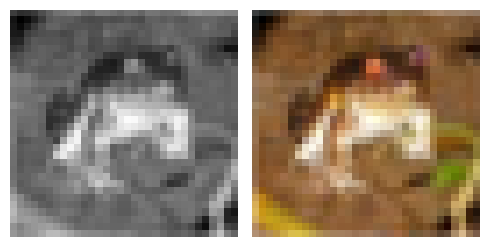

In [ ]:
a,b = trn_ds[0]
subplots([a,b], nc=2)

In [ ]:
# 3 classes para criar a arquitetura da unidade
#retorna o tensor de entrada
class Identity(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return x
#descendente da unidade
class DownConv(nn.Module):
    def __init__(self, ni, no, maxpool=True):
        super().__init__()
        self.model = nn.Sequential(
            nn.MaxPool2d(2) if maxpool else Identity(),
            nn.Conv2d(ni, no, 3, padding=1),
            nn.BatchNorm2d(no),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(no, no, 3, padding=1),
            nn.BatchNorm2d(no),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x):
        return self.model(x)
#ascendente da unidade
class UpConv(nn.Module):
    def __init__(self, ni, no):
        super().__init__()
        self.convtranspose = nn.ConvTranspose2d(ni, no, 2, stride=2)
        self.convlayers = nn.Sequential(
            nn.Conv2d(no+no, no, 3, padding=1),
            nn.BatchNorm2d(no),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(no, no, 3, padding=1),
            nn.BatchNorm2d(no),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x, y):
        x = self.convtranspose(x)
        x = torch.cat([x, y], axis=1)
        x = self.convlayers(x)
        return x

#estende o módulo e cria a arquitetura completa
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        #criação instâncias das classes
        self.d1 = DownConv(3, 64, maxpool=False)
        self.d2 = DownConv(64, 128)
        self.d3 = DownConv(128, 256)
        self.d4 = DownConv(256, 512)
        self.d5 = DownConv(512, 1024)

        self.u5 = UpConv(1024, 512)
        self.u4 = UpConv(512, 256)
        self.u3 = UpConv(256, 128)
        self.u2 = UpConv(128, 64)

        self.u1 = nn.Conv2d(64, 3, kernel_size=1, stride=1)

    #método para criar a unidade completa
    def forward(self, x):
        x0 = self.d1(x)
        x1 = self.d2(x0)
        x2 = self.d3(x1)
        x3 = self.d4(x2)
        x4 = self.d5(x3)

        X4 = self.u5(x4, x3)
        X3 = self.u4(X4, x2)
        X2 = self.u3(X3, x1)
        X1 = self.u2(X2, x0)
        X0 = self.u1(X1)

        return X0

In [ ]:
#cria a instância da classe
def get_model():
    model = UNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3) # otimizador
    loss_fn = nn.MSELoss()
    return model, optimizer, loss_fn #retorna otimizador e a função de perda de unidade

In [ ]:
#valida o patch que realiza passagens
def train_batch(model, data, optimizer, criterion):
    model.train()
    x, y = data
    _y = model(x)
    optimizer.zero_grad()
    loss = criterion(_y, y)
    loss.backward()
    optimizer.step()
    return loss.item() # clacula a perda e retorna

@torch.no_grad()
def validate_batch(model, data, criterion):
    model.eval()
    x, y = data
    _y = model(x)
    loss = criterion(_y, y)
    return loss.item()

EPOCH: 0.250  trn_loss: 0.008  (1536.22s - 612952.73s remaining)

EPOCH: 0.255  trn_loss: 0.008  (1566.08s - 612337.13s remaining)

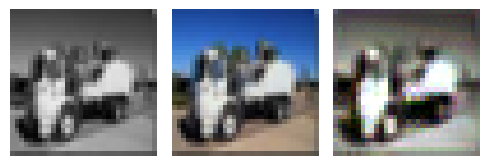

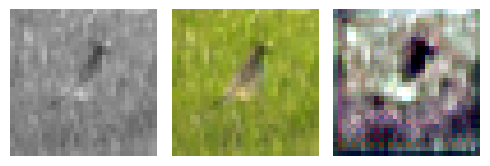

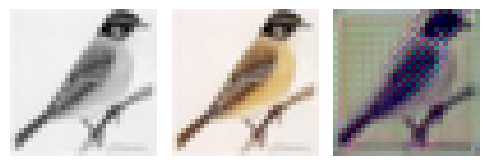

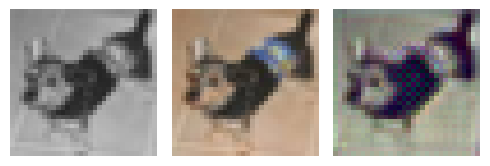

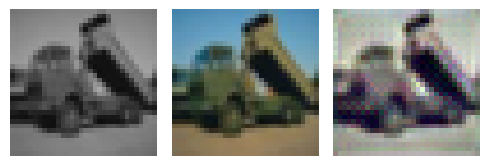

EPOCH: 0.505  trn_loss: 0.007  (3077.42s - 606190.05s remaining)

EPOCH: 0.510  trn_loss: 0.006  (3109.19s - 606292.50s remaining)

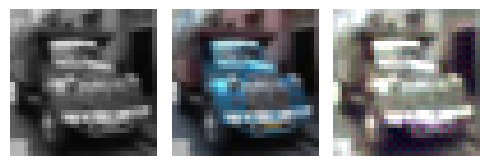

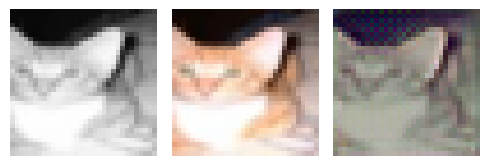

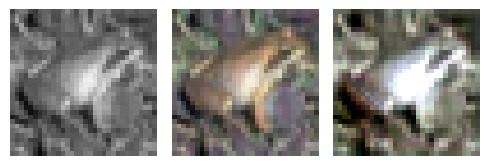

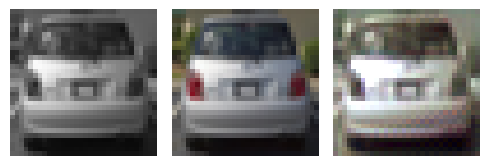

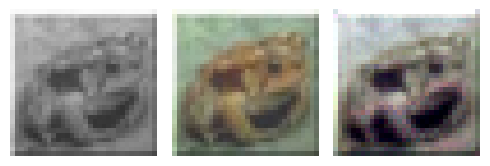

EPOCH: 0.760  trn_loss: 0.007  (4651.65s - 607243.03s remaining)

EPOCH: 0.765  trn_loss: 0.006  (4681.75s - 607066.97s remaining)

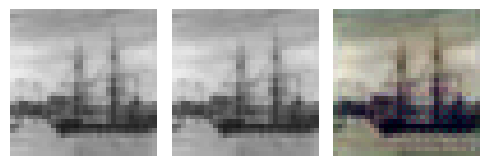

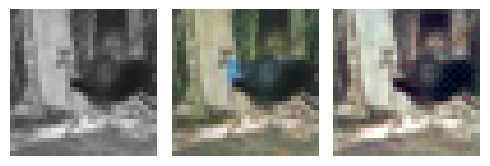

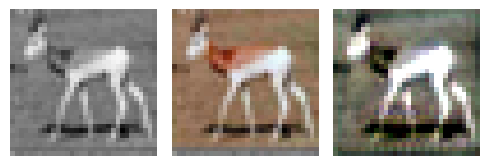

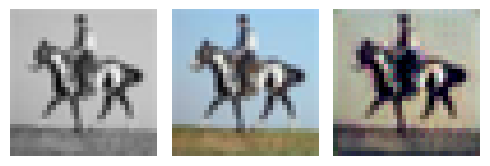

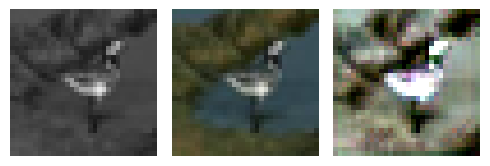

EPOCH: 1.000  val_loss: 0.004  (6436.48s - 637211.38s remaining)

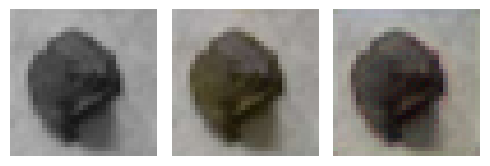

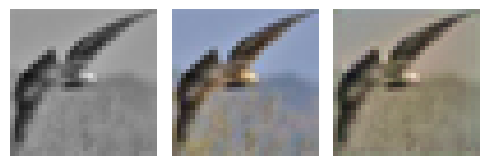

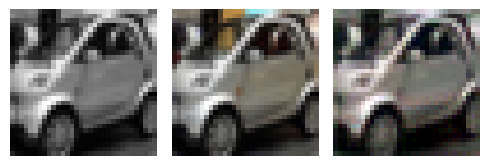

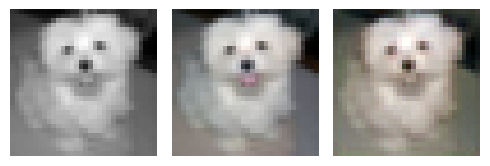

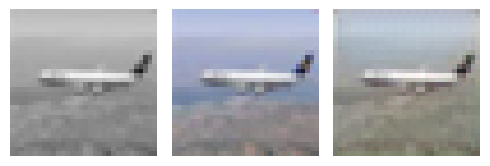

EPOCH: 1.015  trn_loss: 0.007  (6529.41s - 636568.23s remaining)

In [ ]:
model, optimizer, criterion = get_model() #cria o modelo
exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

_val_dl = DataLoader(val_ds, batch_size=1, shuffle=True) #dataloader para teste

n_epochs = 100 # 100 epócas
log = Report(n_epochs)
for ex in range(n_epochs):
    N = len(trn_dl)
    for bx, data in enumerate(trn_dl):
        loss = train_batch(model, data, optimizer, criterion)
        log.record(ex+(bx+1)/N, trn_loss=loss, end='\r') # treina e guarda o erro
        if (bx+1)%50 == 0:
            for _ in range(5):
                a,b = next(iter(_val_dl))
                _b = model(a)
                subplots([a[0], b[0], _b[0]], nc=3, figsize=(5,5)) #pega o input real e a previsão

    N = len(val_dl)
    for bx, data in enumerate(val_dl):
        loss = validate_batch(model, data, criterion)
        log.record(ex+(bx+1)/N, val_loss=loss, end='\r')

    exp_lr_scheduler.step() #atualiza a taxa de aprendizado
    if (ex+1) % 5 == 0: log.report_avgs(ex+1)

    for _ in range(5):
        a,b = next(iter(_val_dl))
        _b = model(a) #faz previsao
        subplots([a[0], b[0], _b[0]], nc=3, figsize=(5,5))

log.plot(log=True)